# Notebook 03: Feature Engineering, Scaling & PCA
## Credit Risk & Loan Amount Prediction | LendingClub

This notebook covers three sequential steps that prepare the clean dataset
from notebook 02 for model training:

**Step 1 — Feature Engineering**
We create new features derived from existing ones that better capture the
underlying financial relationships. Good features reduce the burden on the
model to discover these relationships on its own.

**Step 2 — Scaling**
We standardize all numerical features to have zero mean and unit variance.
This is required before PCA and benefits logistic regression significantly.

**Step 3 — PCA**
We apply Principal Component Analysis to reduce dimensionality, eliminate
multicollinearity, and visualize the variance structure of the feature space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.3f" % x)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

RANDOM_STATE = 42

df = pd.read_parquet("../data/loans_cleaned.parquet")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 914,430 rows x 87 columns


## Step 1: Feature Engineering

We create five new features grounded in financial domain knowledge.
Each feature is designed to capture a relationship that raw columns
express poorly on their own.

The goal is to give the model pre-computed signals that would otherwise
require complex interactions between multiple columns to discover.

In [2]:
# Drop redundant and leakage-adjacent columns identified at the end of notebook 02
# funded_amnt and funded_amnt_inv are determined post-approval, nearly identical to loan_amnt
# fico_range_high is redundant with fico_range_low (10-point band, correlation ~1.0)
# policy_code has a single unique value across the entire dataset — zero variance

cols_to_drop = ["funded_amnt", "funded_amnt_inv", "fico_range_high", "policy_code"]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Shape after dropping redundant columns: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape after dropping redundant columns: 914,430 rows x 83 columns


In [3]:
# Feature 1: loan_to_income_ratio
# Measures how large the loan is relative to the borrower's annual income
# A borrower taking a $20,000 loan on $30,000 income is far riskier than
# one taking the same loan on $100,000 income
df["loan_to_income_ratio"] = df["loan_amnt"] / (df["annual_inc"] + 1)

# Feature 2: installment_to_income_ratio
# Monthly debt burden as a fraction of implied monthly income
# Captures affordability of the monthly payment more directly than dti alone
df["installment_to_income_ratio"] = df["installment"] / (df["annual_inc"] / 12 + 1)

# Feature 3: credit_utilization_risk
# Interaction between revolving utilization and credit score
# High utilization combined with low credit score is a compounding risk signal
df["credit_utilization_risk"] = df["revol_util"] * (850 - df["fico_range_low"])

# Feature 4: delinquency_score
# Composite measure of past delinquency behavior across multiple dimensions
# Borrowers with multiple delinquency indicators are cumulatively higher risk
df["delinquency_score"] = (
    df["delinq_2yrs"] +
    df["num_tl_90g_dpd_24m"] +
    df["num_tl_30dpd"] +
    df["acc_now_delinq"]
)

# Feature 5: credit_history_depth
# Total number of accounts reflects how long and broadly a borrower has
# used credit — deeper history generally indicates more financial stability
df["credit_history_depth"] = df["total_acc"] + df["open_acc"]

print("New features created successfully.")
print()
print(df[["loan_to_income_ratio", "installment_to_income_ratio",
          "credit_utilization_risk", "delinquency_score",
          "credit_history_depth"]].describe())

New features created successfully.

       loan_to_income_ratio  installment_to_income_ratio  \
count            914430.000                   914430.000   
mean                  0.215                        0.079   
std                   0.135                        0.050   
min                   0.004                        0.001   
25%                   0.122                        0.045   
50%                   0.196                        0.071   
75%                   0.288                        0.104   
max                  19.973                        6.340   

       credit_utilization_risk  delinquency_score  credit_history_depth  
count               914430.000         914430.000            914430.000  
mean                  8007.791              0.437                36.715  
std                   4508.111              1.349                16.757  
min                      0.000              0.000                 2.000  
25%                   4433.000              0.000    

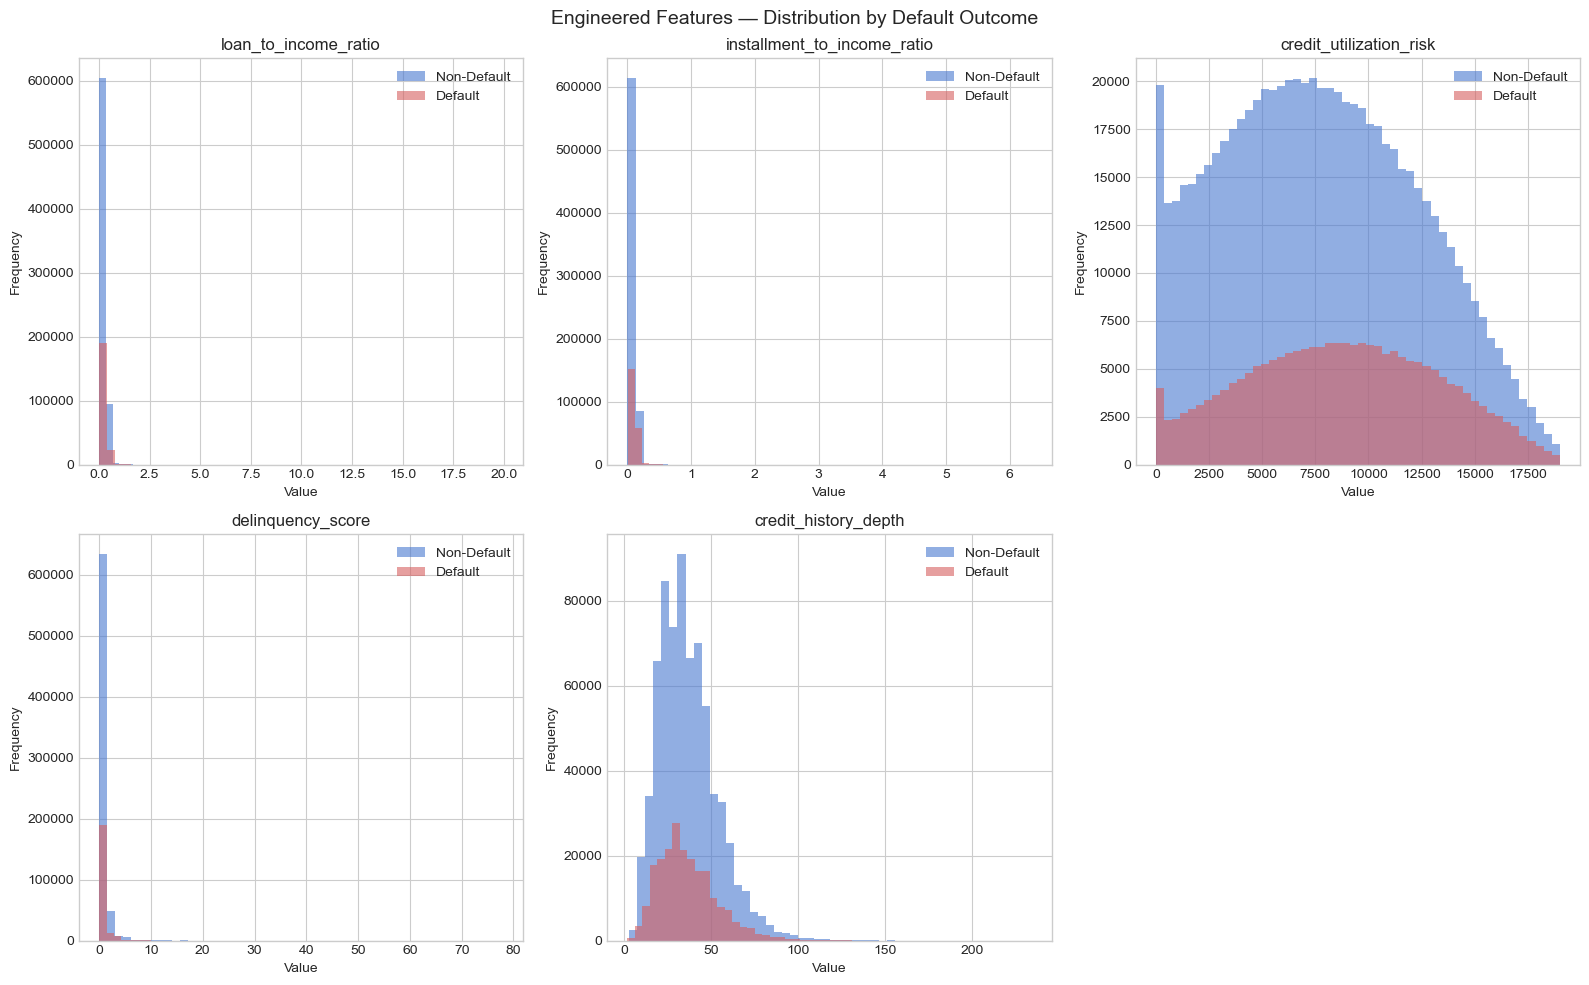

In [4]:
# Visualize the distribution of each engineered feature split by default outcome
# This confirms whether the new features carry discriminative signal

new_features = [
    "loan_to_income_ratio",
    "installment_to_income_ratio",
    "credit_utilization_risk",
    "delinquency_score",
    "credit_history_depth"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    # Plot distribution for defaulters and non-defaulters separately
    axes[i].hist(df[df["default"] == 0][col], bins=50, alpha=0.6,
                 label="Non-Default", color=sns.color_palette("muted")[0])
    axes[i].hist(df[df["default"] == 1][col], bins=50, alpha=0.6,
                 label="Default", color=sns.color_palette("muted")[3])
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

axes[-1].set_visible(False)

fig.suptitle("Engineered Features — Distribution by Default Outcome", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Cap engineered features at 99th percentile to eliminate distorting outliers
# The extreme values in ratio features are compressing the visible distribution

ratio_features = ["loan_to_income_ratio", "installment_to_income_ratio"]

for col in ratio_features:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

print("Engineered features capped at 99th percentile.")
print()
print(df[ratio_features].describe())

Engineered features capped at 99th percentile.

       loan_to_income_ratio  installment_to_income_ratio
count            914430.000                   914430.000
mean                  0.212                        0.079
std                   0.116                        0.044
min                   0.004                        0.001
25%                   0.122                        0.045
50%                   0.196                        0.071
75%                   0.288                        0.104
max                   0.517                        0.210


## Step 2: Train-Test Split

We split the data before scaling and PCA. This is a critical ordering decision —
scaling and PCA must be fit on training data only and then applied to test data.

Fitting the scaler on the full dataset before splitting would cause data leakage:
the test set would influence the scaling parameters, giving the model indirect
access to test set information during training. We prevent this by splitting first.

We use an 80/20 split with stratification on the default label to ensure both
train and test sets maintain the same 23.29% default rate.

In [6]:
# Separate features and targets before splitting
# We maintain two separate target vectors — one for each modeling task

X = df.drop(columns=["default", "loan_amnt"])
y_class = df["default"]
y_reg = df["loan_amnt"]

# Stratified split preserves the 23.29% default rate in both train and test sets
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_class
)

print(f"Training set   : {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"Test set       : {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")
print()
print(f"Default rate in train : {y_train_class.mean() * 100:.2f}%")
print(f"Default rate in test  : {y_test_class.mean() * 100:.2f}%")

Training set   : 731,544 rows x 86 columns
Test set       : 182,886 rows x 86 columns

Default rate in train : 23.29%
Default rate in test  : 23.29%


## Step 3: Standardization

StandardScaler transforms each feature to have zero mean and unit variance.
This is essential for two reasons in our pipeline:

1. **PCA requirement** — PCA finds directions of maximum variance. If features
   are on different scales, PCA will be dominated by high-magnitude features
   like `revol_bal` (thousands) over `dti` (0-100), producing misleading
   components. Standardization ensures every feature contributes equally.

2. **Logistic Regression requirement** — Logistic regression uses gradient
   descent which converges much faster and more reliably when features are
   on the same scale.

Tree-based models (Decision Tree, Random Forest) do not require scaling but
applying it does not harm them either, so we scale the full feature set
for consistency across all models.

The scaler is fit on training data only and applied to both train and test sets.

In [7]:
# Fit StandardScaler on training data only
# Applying transform to both train and test using training parameters only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe to retain column names for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Standardization complete.")
print()
print("Verification — mean and std of first 5 features in training set:")
print()
print(X_train_scaled.iloc[:, :5].describe().loc[["mean", "std"]])

Standardization complete.

Verification — mean and std of first 5 features in training set:

      term  int_rate  installment  grade  sub_grade
mean 0.000    -0.000       -0.000  0.000      0.000
std  1.000     1.000        1.000  1.000      1.000


## Step 4: Principal Component Analysis

PCA serves two purposes in this pipeline:

1. **Multicollinearity elimination** — Features like loan_amnt and installment
   (r = 0.95) violate the independence assumption of logistic regression.
   PCA components are mathematically guaranteed to be uncorrelated.

2. **Dimensionality reduction** — We reduce 83 features to a smaller set of
   components that collectively explain 95% of the variance, removing noise
   while retaining the vast majority of information.

We first run PCA on all components to examine the explained variance curve,
then select the number of components that reach our 95% threshold.

In [8]:
# Run PCA on all components first to examine the full variance structure
# This tells us how many components we need before we commit to a number
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

# Compute cumulative explained variance across all components
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Find the number of components needed to reach 95% explained variance
n_components_95 = np.argmax(cumulative_variance >= 95) + 1

print(f"Total features going into PCA : {X_train_scaled.shape[1]}")
print(f"Components needed for 95% variance: {n_components_95}")
print()
print("Variance explained by first 10 components:")
for i, var in enumerate(pca_full.explained_variance_ratio_[:10] * 100):
    print(f"  PC{i+1:02d}: {var:.2f}%  |  Cumulative: {cumulative_variance[i]:.2f}%")

Total features going into PCA : 86
Components needed for 95% variance: 53

Variance explained by first 10 components:
  PC01: 12.16%  |  Cumulative: 12.16%
  PC02: 6.61%  |  Cumulative: 18.77%
  PC03: 6.01%  |  Cumulative: 24.78%
  PC04: 4.51%  |  Cumulative: 29.29%
  PC05: 3.80%  |  Cumulative: 33.09%
  PC06: 3.39%  |  Cumulative: 36.48%
  PC07: 2.93%  |  Cumulative: 39.40%
  PC08: 2.46%  |  Cumulative: 41.87%
  PC09: 2.23%  |  Cumulative: 44.09%
  PC10: 2.20%  |  Cumulative: 46.29%


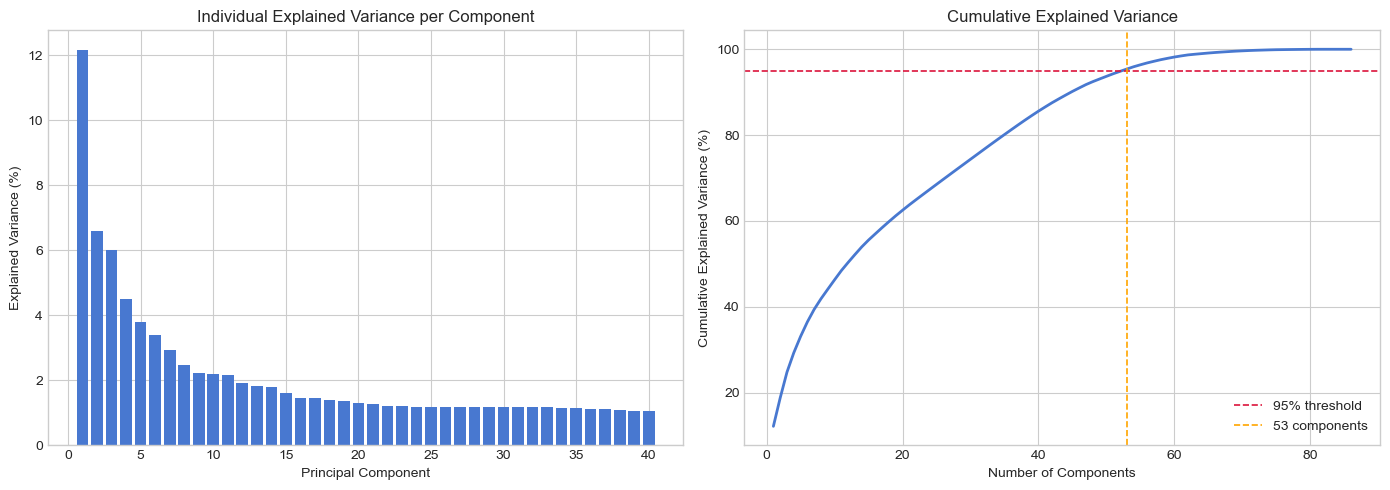

In [9]:
# Scree plot — visualizes explained variance per component and cumulative total
# The elbow point where the curve flattens indicates diminishing returns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance per component (first 40 for readability)
axes[0].bar(range(1, 41),
            pca_full.explained_variance_ratio_[:40] * 100,
            color=sns.color_palette("muted")[0])
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Individual Explained Variance per Component")

# Cumulative explained variance with threshold line
axes[1].plot(range(1, len(cumulative_variance) + 1),
             cumulative_variance,
             color=sns.color_palette("muted")[0], linewidth=2)
axes[1].axhline(y=95, color="crimson", linestyle="--",
                linewidth=1.2, label="95% threshold")
axes[1].axvline(x=n_components_95, color="orange", linestyle="--",
                linewidth=1.2, label=f"{n_components_95} components")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Apply PCA with the selected number of components
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Convert to dataframe with named components for clarity
pca_cols = [f"PC{i+1:02d}" for i in range(n_components_95)]
X_train_pca = pd.DataFrame(X_train_pca, columns=pca_cols)
X_test_pca = pd.DataFrame(X_test_pca, columns=pca_cols)

print(f"PCA applied successfully.")
print(f"Training set shape after PCA : {X_train_pca.shape}")
print(f"Test set shape after PCA     : {X_test_pca.shape}")
print(f"Variance retained            : {pca.explained_variance_ratio_.sum() * 100:.2f}%")

PCA applied successfully.
Training set shape after PCA : (731544, 53)
Test set shape after PCA     : (182886, 53)
Variance retained            : 95.39%


In [11]:
# Save all processed datasets and fitted objects for use in notebooks 04 and 05
# We save both PCA-transformed and scaled (non-PCA) versions
# Classification models will use PCA version
# Regression models will use scaled version for coefficient interpretability

import joblib

# Scaled datasets — used for regression and tree models
X_train_scaled.to_parquet("../data/X_train_scaled.parquet", index=False)
X_test_scaled.to_parquet("../data/X_test_scaled.parquet", index=False)

# PCA transformed datasets — used for logistic regression classifier
X_train_pca.to_parquet("../data/X_train_pca.parquet", index=False)
X_test_pca.to_parquet("../data/X_test_pca.parquet", index=False)

# Target vectors
y_train_class.reset_index(drop=True).to_frame().to_parquet("../data/y_train_class.parquet", index=False)
y_test_class.reset_index(drop=True).to_frame().to_parquet("../data/y_test_class.parquet", index=False)
y_train_reg.reset_index(drop=True).to_frame().to_parquet("../data/y_train_reg.parquet", index=False)
y_test_reg.reset_index(drop=True).to_frame().to_parquet("../data/y_test_reg.parquet", index=False)

# Save fitted scaler and PCA objects for deployment
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")

print("All datasets and model objects saved successfully.")
print()
print("Files saved to data/:")
print("  X_train_scaled, X_test_scaled — for regression and tree models")
print("  X_train_pca, X_test_pca       — for logistic regression")
print("  y_train_class, y_test_class   — classification targets")
print("  y_train_reg, y_test_reg       — regression targets")
print()
print("Files saved to models/:")
print("  scaler.pkl, pca.pkl")

All datasets and model objects saved successfully.

Files saved to data/:
  X_train_scaled, X_test_scaled — for regression and tree models
  X_train_pca, X_test_pca       — for logistic regression
  y_train_class, y_test_class   — classification targets
  y_train_reg, y_test_reg       — regression targets

Files saved to models/:
  scaler.pkl, pca.pkl
